In [14]:
# ============================================================
# MAD Risk Score — CivilComments-WILDS (NLP Toxicity)
# Group DRO's canonical NLP benchmark; text-modality replication
#
# MOTIVATION:
#   CivilComments-WILDS is the other canonical Group DRO benchmark
#   from Sagawa et al. (2020). Comments are labeled as toxic/non-toxic.
#   Demographic annotations mark whether each comment mentions
#   a demographic group (e.g., 'male', 'female', 'LGBTQ', 'Muslim',
#   'Black', 'White', etc.). Group DRO is supposed to improve
#   worst-group accuracy across these demographic groups.
#
#   MINORITY-WITHIN-MINORITY STRUCTURE:
#   We identify the demographic group × toxicity label cell
#   with the lowest prevalence (analogous to dark-skin benign).
#   Typical worst case: comments mentioning a small demographic
#   group that are labeled as non-toxic (correct label),
#   but Group DRO collapses accuracy on that cell.
#
# EXPERIMENTAL DESIGN (identical protocol to Fitzpatrick):
#   Backbone: frozen DistilBERT-base-uncased (CLS token embedding)
#             — 768-dim, CPU-extractable, same geometry framework
#   Majority split: train on comments NOT mentioning minority demo group
#   Minority split: test on comments mentioning minority demo group
#   Target: toxicity classification (binary: toxic=1 / non-toxic=0)
#   Minority class: toxic comments within minority demographic
#                   OR non-toxic comments (whichever is rarer)
#   Groups: demographic_mentioned x toxicity_label -> N groups
#   Interventions: Baseline ERM, Group DRO (eta=0.1), SMOTE
#   nc/Ng sweep: 8 levels
#   5 seeds: [42, 0, 1, 7, 99]
#
# KEY QUESTION:
#   Does frozen text embedding geometry (μ_cosine over DistilBERT
#   CLS tokens) predict Group DRO collapse, as it does for CLIP
#   image embeddings in dermatology?
#
# DATASET:
#   CivilComments-WILDS (Borkan et al. 2019 + WILDS benchmark)
#   Available via: wilds library OR direct CSV from CivilComments
#   Kaggle: google-jigsaw/jigsaw-toxic-comment-classification-challenge
#   OR wilds package downloads it automatically
#
# OUTPUT:
#   mad_civilcomments_results.csv
#   mad_civilcomments_sweep.csv
#   mad_civilcomments_figure.png
#   mad_civilcomments_summary.json
#
# RUNTIME: ~2h on Kaggle T4
# Kaggle: GPU T4, Internet ON
# ============================================================

!pip install transformers torch torchvision scikit-learn imbalanced-learn pandas numpy matplotlib wilds -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import os, json, warnings, math
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
from transformers import DistilBertModel, DistilBertTokenizerFast
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
DRO_ETA      = 0.1
N_EPOCHS     = 5
BATCH_SIZE   = 64
ADAMW_LR     = 1e-4
ADAMW_WD     = 1e-2
FEAT_DIM     = 768
COLLAPSE_THR = 0.01
MAD_I_GATE   = 0.02
FITZ_TAU_BASE = 0.086
FITZ_TAU_W   = 0.131
MAX_SEQ_LEN  = 128  # DistilBERT input length (cost/speed tradeoff)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.5 MB/s eta 0:00:00
Device: cuda


In [15]:
# ── CELL 2: Load CivilComments / Jigsaw Unintended Bias ───────
# WILDS path skipped — use the Jigsaw CSV directly (already in /kaggle/input).
# Column name is 'target' (float 0-1), not 'toxicity' or 'toxic'.

df_train_raw = None
DEMO_COLS = []

# ── Find the train CSV ─────────────────────────────────────────
jigsaw_train = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'train.csv':
            jigsaw_train = os.path.join(root, f)
            break
    if jigsaw_train:
        break

if jigsaw_train is None:
    raise FileNotFoundError(
        'train.csv not found in /kaggle/input.\n'
        'Add jigsaw-unintended-bias-in-toxicity-classification to Kaggle input.')

print(f'Loading: {jigsaw_train}')
df_raw = pd.read_csv(jigsaw_train)
print(f'Rows: {len(df_raw):,}   Columns: {df_raw.columns.tolist()[:25]}')

# ── Toxicity label ────────────────────────────────────────────
# This dataset uses 'target' (float 0-1 mean annotator score)
TOX_COL = None
for candidate in ['target', 'toxicity', 'toxic']:
    if candidate in df_raw.columns:
        TOX_COL = candidate
        break
if TOX_COL is None:
    raise ValueError(f"No toxicity column found. Columns: {df_raw.columns.tolist()}")

df_raw['toxicity'] = (df_raw[TOX_COL] >= 0.5).astype(int)
print(f'Toxicity column: "{TOX_COL}" -> binarized at >= 0.5')
print(f'Toxic: {df_raw.toxicity.sum():,}  Non-toxic: {(df_raw.toxicity==0).sum():,}')

# ── Demographic columns ───────────────────────────────────────
DEMO_WANT = ['male', 'female', 'homosexual_gay_or_lesbian', 'christian',
             'muslim', 'black', 'white', 'psychiatric_or_mental_illness',
             'jewish', 'latino', 'transgender']
DEMO_COLS = [c for c in DEMO_WANT if c in df_raw.columns]
print(f'Demographic columns: {DEMO_COLS}')

# Binarize demo cols: NaN -> 0 (not mentioned), >= 0.5 -> 1 (mentioned)
for col in DEMO_COLS:
    df_raw[col] = (df_raw[col].fillna(0.0) >= 0.5).astype(int)

df_raw['text'] = df_raw['comment_text']

# Drop rows missing text
df_raw = df_raw.dropna(subset=['text', 'toxicity']).reset_index(drop=True)
print(f'After dropna: {len(df_raw):,} rows')

# ── Train/test split (80/20, stratified by toxicity) ──────────
# Cap total size for compute budget
MAX_TOTAL = 50000
if len(df_raw) > MAX_TOTAL:
    # Stratified sample
    toxic_rows    = df_raw[df_raw.toxicity == 1].sample(
        min(int(MAX_TOTAL * 0.15), (df_raw.toxicity==1).sum()), random_state=42)
    nontoxic_rows = df_raw[df_raw.toxicity == 0].sample(
        MAX_TOTAL - len(toxic_rows), random_state=42)
    df_raw = pd.concat([toxic_rows, nontoxic_rows]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'Capped to {len(df_raw):,} rows (stratified)')

idx  = np.random.RandomState(42).permutation(len(df_raw))
n_tr = int(0.8 * len(idx))
df_train_raw = df_raw.iloc[idx[:n_tr]].reset_index(drop=True)
df_test_raw  = df_raw.iloc[idx[n_tr:]].reset_index(drop=True)

print(f'\nTrain: {len(df_train_raw):,}   Test: {len(df_test_raw):,}')
print(f'Train toxicity dist: {dict(df_train_raw.toxicity.value_counts().sort_index())}')
print(f'Test  toxicity dist: {dict(df_test_raw.toxicity.value_counts().sort_index())}')
print('\nDemo group mention rates (test):')
for col in DEMO_COLS:
    n = int(df_test_raw[col].sum())
    print(f'  {col}: {n} ({n/len(df_test_raw)*100:.1f}%)')

print('\nDataset ready.')

Loading: /kaggle/input/datasets/julian3833/jigsaw-unintended-bias-in-toxicity-classification/train.csv
Rows: 1,804,874   Columns: ['id', 'target', 'comment_text', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability', 'jewish', 'latino', 'male', 'muslim', 'other_disability', 'other_gender']
Toxicity column: "target" -> binarized at >= 0.5
Toxic: 144,334  Non-toxic: 1,660,540
Demographic columns: ['male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'jewish', 'latino', 'transgender']
After dropna: 1,804,871 rows
Capped to 50,000 rows (stratified)

Train: 40,000   Test: 10,000
Train toxicity dist: {0: np.int64(34020), 1: np.int64(5980)}
Test  toxicity dist: {0: np.int64(8480), 1: np.int64(1520)}

Demo group mention rates (test):
  male: 234 

In [16]:
# ── CELL 3: Build demographic split ───────────────────────────
# Find the minority demographic: the one with fewest comments mentioning it
# Among those, find minority class (toxic or non-toxic, whichever is rarer)

if DEMO_COLS:
    # Create 'any_demo_mentioned' flag and identify rarest demo group
    demo_mention_counts = {}
    for col in DEMO_COLS:
        if col in df_test_raw.columns:
            demo_mention_counts[col] = int(df_test_raw[col].sum())
    print('Demo group mention counts (test set):')
    for k, v in sorted(demo_mention_counts.items(), key=lambda x: x[1]):
        print(f'  {k}: {v}')

    # Choose the minority demographic = rarest mentioned group
    MINORITY_DEMO = min(demo_mention_counts, key=demo_mention_counts.get)
    print(f'\nSelected minority demographic: {MINORITY_DEMO}')

    # MAJORITY context: does NOT mention the minority demographic
    # MINORITY context: mentions the minority demographic
    train_majority_mask = df_train_raw[MINORITY_DEMO] == 0
    test_minority_mask  = df_test_raw[MINORITY_DEMO]  == 1
    # Also keep majority test (mentions nothing -> control)
    test_majority_mask  = df_test_raw[MINORITY_DEMO]  == 0
else:
    # Fallback: random 50/50 demo split
    MINORITY_DEMO = 'random_split'
    np.random.seed(42)
    train_majority_mask = np.ones(len(df_train_raw), dtype=bool)  # all train
    test_minority_mask  = np.random.rand(len(df_test_raw)) < 0.3
    test_majority_mask  = ~test_minority_mask

df_tr = df_train_raw[train_majority_mask].copy().reset_index(drop=True)
df_te = df_test_raw[test_minority_mask].copy().reset_index(drop=True)

# Cap size for compute budget
MAX_TRAIN = 20000
MAX_TEST  = 5000
if len(df_tr) > MAX_TRAIN:
    df_tr = df_tr.sample(MAX_TRAIN, random_state=42).reset_index(drop=True)
if len(df_te) > MAX_TEST:
    df_te = df_te.sample(MAX_TEST, random_state=42).reset_index(drop=True)

# Identify minority class in test
n_toxic_test    = int((df_te.toxicity == 1).sum())
n_nontoxic_test = int((df_te.toxicity == 0).sum())
n_total_test    = len(df_te)

MINORITY_CLASS = 1 if n_toxic_test <= n_nontoxic_test else 0
CLASS_NAMES    = {0: 'non-toxic', 1: 'toxic'}
MINORITY_NAME  = CLASS_NAMES[MINORITY_CLASS]
n_minority_test = n_toxic_test if MINORITY_CLASS == 1 else n_nontoxic_test
nc_ng = n_minority_test / n_total_test

print(f'\nTRAIN (majority demo, cap {MAX_TRAIN}): {len(df_tr):,}')
print(f'TEST  (minority demo "{MINORITY_DEMO}", cap {MAX_TEST}): {len(df_te):,}')
print(f'  toxic: {n_toxic_test}  non-toxic: {n_nontoxic_test}')
print(f'Minority class: {MINORITY_NAME} (y={MINORITY_CLASS})')
print(f'nc/Ng = {n_minority_test}/{n_total_test} = {nc_ng:.4f} ({nc_ng*100:.1f}%)')

if nc_ng < MAD_I_GATE:
    print(f'WARNING: nc/Ng < MAD-I gate ({MAD_I_GATE}) -> CONTRAINDICATED')
else:
    print(f'nc/Ng above MAD-I gate -> proceed')

Demo group mention counts (test set):
  latino: 14
  transgender: 20
  psychiatric_or_mental_illness: 37
  jewish: 49
  homosexual_gay_or_lesbian: 71
  black: 97
  muslim: 140
  white: 167
  christian: 215
  male: 234
  female: 274

Selected minority demographic: latino

TRAIN (majority demo, cap 20000): 20,000
TEST  (minority demo "latino", cap 5000): 14
  toxic: 4  non-toxic: 10
Minority class: toxic (y=1)
nc/Ng = 4/14 = 0.2857 (28.6%)
nc/Ng above MAD-I gate -> proceed


In [17]:
# ── CELL 4: Load DistilBERT, extract frozen CLS embeddings ────
print('Loading DistilBERT-base-uncased...')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)
bert_model.eval()
print('DistilBERT loaded.')

def extract_text_features(texts, desc='', batch=64):
    all_feats = []
    for i in range(0, len(texts), batch):
        batch_texts = texts[i:i+batch].tolist() if hasattr(texts, 'iloc') else list(texts[i:i+batch])
        enc = tokenizer(
            batch_texts,
            max_length=MAX_SEQ_LEN,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = bert_model(**enc)
            cls_emb = out.last_hidden_state[:, 0, :]  # CLS token
            cls_emb = cls_emb / cls_emb.norm(dim=-1, keepdim=True)  # L2-normalize
        all_feats.append(cls_emb.cpu().numpy())
        if i % 1280 == 0:
            print(f'  {desc}: {min(i+batch, len(texts))}/{len(texts)}')
    return np.vstack(all_feats)

print('Extracting TRAIN features...')
TR_F = extract_text_features(df_tr['text'].values, desc='train')
TR_L = df_tr['toxicity'].values.astype(int)
# Group: 2 groups (majority demo x toxicity) - since train is all majority demo,
# groups = toxicity label (0 or 1)
TR_G = TR_L.copy()  # 2 groups: non-toxic=0, toxic=1

print('Extracting TEST features...')
TE_F = extract_text_features(df_te['text'].values, desc='test')
TE_L = df_te['toxicity'].values.astype(int)
TE_G = TE_L.copy()

print(f'Train: {TR_F.shape}  Test: {TE_F.shape}')
print(f'Train toxicity: {dict(zip(*np.unique(TR_L, return_counts=True)))}')
print(f'Test toxicity:  {dict(zip(*np.unique(TE_L, return_counts=True)))}')

Loading DistilBERT-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded.
Extracting TRAIN features...
  train: 64/20000
  train: 1344/20000
  train: 2624/20000
  train: 3904/20000
  train: 5184/20000
  train: 6464/20000
  train: 7744/20000
  train: 9024/20000
  train: 10304/20000
  train: 11584/20000
  train: 12864/20000
  train: 14144/20000
  train: 15424/20000
  train: 16704/20000
  train: 17984/20000
  train: 19264/20000
Extracting TEST features...
  test: 14/14
Train: (20000, 768)  Test: (14, 768)
Train toxicity: {np.int64(0): np.int64(17003), np.int64(1): np.int64(2997)}
Test toxicity:  {np.int64(0): np.int64(10), np.int64(1): np.int64(4)}


In [18]:
# ── CELL 5: SEALED ENVELOPE — MAD Risk Score ──────────────────

def mean_pairwise_cosine(X):
    if len(X) < 2:
        return 0.0
    G = X @ X.T  # already L2-normalized
    n = len(X)
    idx = np.triu_indices(n, k=1)
    return float(G[idx].mean())

def compute_mad_scores(mu_cos, n_min, n_maj_demo, n_min_demo, nc_ng_val):
    if nc_ng_val < MAD_I_GATE:
        return None, None, 'MAD-I'
    mad_base = (1 - mu_cos) / math.log(1 + n_min)
    mad_w    = mad_base * math.log(1 + n_maj_demo / n_min_demo) if n_min_demo > 0 else mad_base
    return mad_base, mad_w, 'MAD-G'

min_mask_tr = (TR_L == MINORITY_CLASS)
min_feats_tr = TR_F[min_mask_tr]

# Cap pairwise computation for large sets
if len(min_feats_tr) > 500:
    np.random.seed(42)
    sample_idx = np.random.choice(len(min_feats_tr), 500, replace=False)
    mu_cos = mean_pairwise_cosine(min_feats_tr[sample_idx])
else:
    mu_cos = mean_pairwise_cosine(min_feats_tr)

n_min_train = int(min_mask_tr.sum())
n_maj_demo  = len(df_tr)   # comments NOT mentioning minority demo
n_min_demo  = len(df_te)   # comments mentioning minority demo

mad_base, mad_w, stage = compute_mad_scores(
    mu_cos, n_min_train, n_maj_demo, n_min_demo, nc_ng)

pred_base = ('ELEVATED' if mad_base is not None and mad_base >= FITZ_TAU_BASE
             else ('CONTRAINDICATED' if mad_base is None else 'LOW_RISK'))
pred_w    = ('ELEVATED' if mad_w    is not None and mad_w    >= FITZ_TAU_W
             else ('CONTRAINDICATED' if mad_w    is None else 'LOW_RISK'))

sealed = {
    'domain': 'NLP_toxicity_classification',
    'dataset': 'CivilComments-WILDS',
    'backbone': 'DistilBERT_base_uncased_CLS_frozen',
    'minority_demo': MINORITY_DEMO,
    'minority_class': MINORITY_NAME,
    'nc_ng': round(nc_ng, 4),
    'n_min_train': n_min_train,
    'mu_cosine': round(mu_cos, 4),
    'stage': stage,
    'mad_base': round(mad_base, 4) if mad_base else None,
    'mad_w':    round(mad_w,    4) if mad_w    else None,
    'fitz_tau_base': FITZ_TAU_BASE,
    'fitz_tau_w':    FITZ_TAU_W,
    'pred_base': pred_base,
    'pred_w':    pred_w,
    'n_maj_demo': n_maj_demo,
    'n_min_demo': n_min_demo,
    'note': (
        'NLP modality: frozen DistilBERT CLS token instead of CLIP image embedding. '
        'Tests whether the MAD geometry framework generalizes to text representations. '
        'mu_cosine may differ systematically from image embeddings — domain recalibration expected.'
    )
}
with open('mad_civilcomments_sealed.json', 'w') as fh:
    json.dump(sealed, fh, indent=2)

print('=== SEALED ENVELOPE ===')
print(json.dumps(sealed, indent=2))
print('\n>>> Envelope sealed. DRO runs below. >>>')

=== SEALED ENVELOPE ===
{
  "domain": "NLP_toxicity_classification",
  "dataset": "CivilComments-WILDS",
  "backbone": "DistilBERT_base_uncased_CLS_frozen",
  "minority_demo": "latino",
  "minority_class": "toxic",
  "nc_ng": 0.2857,
  "n_min_train": 2997,
  "mu_cosine": 0.9083,
  "stage": "MAD-G",
  "mad_base": 0.0115,
  "mad_w": 0.0832,
  "fitz_tau_base": 0.086,
  "fitz_tau_w": 0.131,
  "pred_base": "LOW_RISK",
  "pred_w": "LOW_RISK",
  "n_maj_demo": 20000,
  "n_min_demo": 14,
  "note": "NLP modality: frozen DistilBERT CLS token instead of CLIP image embedding. Tests whether the MAD geometry framework generalizes to text representations. mu_cosine may differ systematically from image embeddings \u2014 domain recalibration expected."
}

>>> Envelope sealed. DRO runs below. >>>


In [19]:
# ── CELL 6: Classifier + Group DRO (identical to vision protocol) ─

class LinearClassifier(nn.Module):
    def __init__(self, in_dim=FEAT_DIM, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)
    def forward(self, x):
        return self.fc(x)

def make_loaders(tr_f, tr_l, tr_g, te_f, te_l, te_g):
    tr_ds = TensorDataset(torch.from_numpy(tr_f).float(),
                          torch.from_numpy(tr_l).long(),
                          torch.from_numpy(tr_g).long())
    te_ds = TensorDataset(torch.from_numpy(te_f).float(),
                          torch.from_numpy(te_l).long(),
                          torch.from_numpy(te_g).long())
    return (DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True),
            DataLoader(te_ds, batch_size=BATCH_SIZE*4, shuffle=False))

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for xb, yb, _ in loader:
            all_logits.append(model(xb.to(device)).cpu())
            all_labels.append(yb)
    logits = torch.cat(all_logits); labels = torch.cat(all_labels).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = logits.argmax(dim=1).numpy()
    acc = accuracy_score(labels, preds)
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except:
        auc = float('nan')
    per_class = {}
    for c in np.unique(labels):
        mask = labels == c
        per_class[int(c)] = float(accuracy_score(labels[mask], preds[mask]))
    return acc, auc, per_class


def run_baseline(tr_f, tr_l, te_f, te_l, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    g_dummy = np.zeros(len(tr_l), dtype=int)
    g_te    = np.zeros(len(te_l), dtype=int)
    tr_ld, te_ld = make_loaders(tr_f, tr_l, g_dummy, te_f, te_l, g_te)
    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    crit  = nn.CrossEntropyLoss()
    for _ in range(N_EPOCHS):
        model.train()
        for xb, yb, _ in tr_ld:
            opt.zero_grad(); crit(model(xb.to(device)), yb.to(device)).backward(); opt.step()
    _, auc, pc = evaluate(model, te_ld)
    return auc, pc


def run_group_dro(tr_f, tr_l, tr_g, te_f, te_l, te_g, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_ld, te_ld = make_loaders(tr_f, tr_l, tr_g, te_f, te_l, te_g)
    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    n_groups = len(np.unique(tr_g))
    q = torch.ones(n_groups).to(device) / n_groups
    wt_trace = []
    minority_group_idx = int(MINORITY_CLASS)  # toxic=1 or non-toxic=0

    for epoch in range(N_EPOCHS):
        model.train()
        for xb, yb, gb in tr_ld:
            xb, yb, gb = xb.to(device), yb.to(device), gb.to(device)
            opt.zero_grad()
            logits = model(xb)
            losses = nn.CrossEntropyLoss(reduction='none')(logits, yb)
            g_loss = torch.zeros(n_groups).to(device)
            for g in range(n_groups):
                mask = gb == g
                if mask.sum() > 0:
                    g_loss[g] = losses[mask].mean()
            q = q * torch.exp(DRO_ETA * g_loss.detach())
            q = q / q.sum()
            loss = (q * g_loss).sum()
            loss.backward(); opt.step()
        min_w = float(q[minority_group_idx].item()) if minority_group_idx < n_groups else float(q.min())
        wt_trace.append(min_w)

    _, auc, pc = evaluate(model, te_ld)
    collapsed = wt_trace[-1] < COLLAPSE_THR
    return auc, pc, wt_trace[-1], collapsed, wt_trace


def run_smote(tr_f, tr_l, te_f, te_l, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    try:
        k = min(5, int(sum(tr_l == MINORITY_CLASS)) - 1)
        sm = SMOTE(random_state=seed, k_neighbors=max(1, k))
        tr_f_aug, tr_l_aug = sm.fit_resample(tr_f, tr_l)
    except Exception as e:
        print(f'  SMOTE failed ({e}), using original')
        tr_f_aug, tr_l_aug = tr_f, tr_l
    g_dummy = np.zeros(len(tr_l_aug), dtype=int)
    g_te    = np.zeros(len(te_l),     dtype=int)
    tr_ld, te_ld = make_loaders(tr_f_aug, tr_l_aug, g_dummy, te_f, te_l, g_te)
    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    crit  = nn.CrossEntropyLoss()
    for _ in range(N_EPOCHS):
        model.train()
        for xb, yb, _ in tr_ld:
            opt.zero_grad(); crit(model(xb.to(device)), yb.to(device)).backward(); opt.step()
    _, auc, pc = evaluate(model, te_ld)
    return auc, pc


def run_random_split_auc(all_f, all_l, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    idx = np.random.permutation(len(all_l))
    split = int(0.75 * len(idx))
    g_dummy = np.zeros(split, dtype=int)
    g_te_d  = np.zeros(len(idx)-split, dtype=int)
    tr_ld, te_ld = make_loaders(all_f[idx[:split]], all_l[idx[:split]], g_dummy,
                                 all_f[idx[split:]], all_l[idx[split:]], g_te_d)
    model = LinearClassifier().to(device)
    opt   = optim.AdamW(model.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    crit  = nn.CrossEntropyLoss()
    for _ in range(N_EPOCHS):
        model.train()
        for xb, yb, _ in tr_ld:
            opt.zero_grad(); crit(model(xb.to(device)), yb.to(device)).backward(); opt.step()
    _, auc, _ = evaluate(model, te_ld)
    return auc

print('Classifier utilities defined.')

Classifier utilities defined.


In [20]:
# ── CELL 7: Main 5-seed experiment ────────────────────────────

ALL_F = np.vstack([TR_F, TE_F])
ALL_L = np.concatenate([TR_L, TE_L])

records = []

for seed in SEEDS:
    print(f'\n{"="*50}\nSEED {seed}\n{"="*50}')

    rand_auc = run_random_split_auc(ALL_F, ALL_L, seed)
    print(f'  Random-split AUC: {rand_auc:.3f}')

    base_auc, base_pc = run_baseline(TR_F, TR_L, TE_F, TE_L, seed)
    sgg = rand_auc - base_auc
    min_base = base_pc.get(MINORITY_CLASS, float('nan'))
    print(f'  Baseline: AUC={base_auc:.3f}, SGG={sgg:.3f}, {MINORITY_NAME}_acc={min_base:.3f}')

    dro_auc, dro_pc, min_w, collapsed, wt_trace = run_group_dro(
        TR_F, TR_L, TR_G, TE_F, TE_L, TE_G, seed)
    dro_sgg = rand_auc - dro_auc
    min_dro = dro_pc.get(MINORITY_CLASS, float('nan'))
    print(f'  Group DRO: AUC={dro_auc:.3f}, SGG={dro_sgg:.3f}, '
          f'{MINORITY_NAME}_acc={min_dro:.3f}, min_w={min_w:.4f}, collapse={collapsed}')

    smote_auc, smote_pc = run_smote(TR_F, TR_L, TE_F, TE_L, seed)
    min_smote = smote_pc.get(MINORITY_CLASS, float('nan'))
    print(f'  SMOTE: AUC={smote_auc:.3f}, {MINORITY_NAME}_acc={min_smote:.3f}')

    for name, auc, pc, wt_col, col_flag, wt_tr in [
        ('Baseline',  base_auc,  base_pc,  None,  None,      None),
        ('Group_DRO', dro_auc,   dro_pc,   min_w, collapsed, wt_trace),
        ('SMOTE',     smote_auc, smote_pc, None,  None,      None),
    ]:
        rec = {
            'seed': seed,
            'intervention': name,
            'rand_auc': round(rand_auc, 4),
            'demo_auc': round(auc, 4),
            'sgg': round(rand_auc - auc, 4),
            'minority_class_acc': round(pc.get(MINORITY_CLASS, float('nan')), 4),
            'majority_class_acc': round(pc.get(1 - MINORITY_CLASS, float('nan')), 4),
            'min_weight': round(wt_col, 4) if wt_col is not None else None,
            'weight_collapse': bool(col_flag) if col_flag is not None else None,
        }
        if wt_tr:
            rec['wt_trace'] = [round(w, 4) for w in wt_tr]
        records.append(rec)

df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'wt_trace'} for r in records])
df_res.to_csv('mad_civilcomments_results.csv', index=False)
print('\nResults saved: mad_civilcomments_results.csv')


SEED 42
  Random-split AUC: 0.600
  Baseline: AUC=0.650, SGG=-0.050, toxic_acc=0.000
  Group DRO: AUC=0.650, SGG=-0.050, toxic_acc=0.500, min_w=0.5027, collapse=False
  SMOTE: AUC=0.600, toxic_acc=0.500

SEED 0
  Random-split AUC: 0.585
  Baseline: AUC=0.650, SGG=-0.065, toxic_acc=0.000
  Group DRO: AUC=0.650, SGG=-0.065, toxic_acc=0.500, min_w=0.5089, collapse=False
  SMOTE: AUC=0.600, toxic_acc=0.500

SEED 1
  Random-split AUC: 0.588
  Baseline: AUC=0.600, SGG=-0.012, toxic_acc=0.000
  Group DRO: AUC=0.650, SGG=-0.062, toxic_acc=0.500, min_w=0.5095, collapse=False
  SMOTE: AUC=0.600, toxic_acc=0.500

SEED 7
  Random-split AUC: 0.585
  Baseline: AUC=0.675, SGG=-0.090, toxic_acc=0.000
  Group DRO: AUC=0.625, SGG=-0.040, toxic_acc=0.500, min_w=0.5075, collapse=False
  SMOTE: AUC=0.600, toxic_acc=0.500

SEED 99
  Random-split AUC: 0.578
  Baseline: AUC=0.650, SGG=-0.072, toxic_acc=0.000
  Group DRO: AUC=0.650, SGG=-0.072, toxic_acc=0.500, min_w=0.5005, collapse=False
  SMOTE: AUC=0.575,

In [21]:
# ── CELL 7b: Force NLP collapse by subsampling to count floor ──
# Current Latino-toxic cell (nc/Ng=0.286) is safe — no collapse.
# Subsample it down toward the Fitzpatrick count floor (~88 examples)
# until Group DRO collapses it. Check that MAD flags it at that count.

print('=== FORCED COLLAPSE EXPERIMENT (CivilComments NLP) ===')
print('Subsampling minority cell to induce collapse...\n')

FORCE_SEEDS   = [42, 0, 1]
# Target counts to try — start at current, descend toward floor
TARGET_COUNTS = [400, 200, 100, 50, 25]

min_idx_tr = np.where(TR_L == MINORITY_CLASS)[0]
maj_idx_tr = np.where(TR_L != MINORITY_CLASS)[0]

force_records = []

for target_n in TARGET_COUNTS:
    if target_n >= len(min_idx_tr):
        sel_min_tr = min_idx_tr
    else:
        np.random.seed(42)
        sel_min_tr = np.random.choice(min_idx_tr, target_n, replace=False)

    sub_tr_f = TR_F[np.concatenate([sel_min_tr, maj_idx_tr])]
    sub_tr_l = TR_L[np.concatenate([sel_min_tr, maj_idx_tr])]
    sub_tr_g = TR_G[np.concatenate([sel_min_tr, maj_idx_tr])]

    actual_n   = len(sel_min_tr)
    actual_nc  = actual_n / len(sub_tr_l)

    # Compute MAD score at this count
    cell_feats = TR_F[sel_min_tr]
    if len(cell_feats) > 500:
        cell_feats = cell_feats[np.random.choice(len(cell_feats), 500, replace=False)]
    mu_sub = mean_pairwise_cosine(cell_feats)
    mad_b_sub, mad_w_sub, stg_sub = compute_mad_scores(
        mu_sub, actual_n, len(maj_idx_tr), actual_n, actual_nc)
    pred_sub = ('ELEVATED' if mad_b_sub is not None and mad_b_sub >= FITZ_TAU_BASE
                else ('CONTRAINDICATED' if mad_b_sub is None else 'LOW_RISK'))

    collapses = 0; accs = []
    for seed in FORCE_SEEDS:
        dro_auc, dro_pc, min_w, collapsed, _ = run_group_dro(
            sub_tr_f, sub_tr_l, sub_tr_g, TE_F, TE_L, TE_G, seed)
        collapses += int(collapsed)
        accs.append(dro_pc.get(MINORITY_CLASS, float('nan')))

    col_rate = collapses / len(FORCE_SEEDS)
    mean_acc = np.nanmean(accs)
    mad_b_str = f'{mad_b_sub:.4f}' if mad_b_sub is not None else 'N/A'
    print(f'  n_min={actual_n:>4}  nc/Ng={actual_nc:.3f}  mu={mu_sub:.4f}  '
          f'MAD_base={mad_b_str}  pred={pred_sub}  '
          f'collapse={collapses}/{len(FORCE_SEEDS)}  '
          f'mean_{MINORITY_NAME}_acc={mean_acc:.3f}')

    force_records.append({
        'n_minority_train': actual_n,
        'nc_ng': round(actual_nc, 4),
        'mu_cosine': round(mu_sub, 4),
        'mad_base': round(mad_b_sub, 4) if mad_b_sub is not None else None,
        'pred_base': pred_sub,
        'collapse_rate': round(col_rate, 3),
        'mean_minority_acc': round(mean_acc, 4),
    })

df_force = pd.DataFrame(force_records)
df_force.to_csv('mad_civilcomments_forced_collapse.csv', index=False)
print('\nForced collapse table:')
print(df_force.to_string())
print('\nKey question: at what n_min does collapse onset, and does MAD_base cross 0.086 there?')

=== FORCED COLLAPSE EXPERIMENT (CivilComments NLP) ===
Subsampling minority cell to induce collapse...

  n_min= 400  nc/Ng=0.023  mu=0.9090  MAD_base=0.0152  pred=LOW_RISK  collapse=0/3  mean_toxic_acc=0.000
  n_min= 200  nc/Ng=0.012  mu=0.9083  MAD_base=N/A  pred=CONTRAINDICATED  collapse=0/3  mean_toxic_acc=0.000
  n_min= 100  nc/Ng=0.006  mu=0.9073  MAD_base=N/A  pred=CONTRAINDICATED  collapse=0/3  mean_toxic_acc=0.000
  n_min=  50  nc/Ng=0.003  mu=0.9047  MAD_base=N/A  pred=CONTRAINDICATED  collapse=0/3  mean_toxic_acc=0.000
  n_min=  25  nc/Ng=0.001  mu=0.9073  MAD_base=N/A  pred=CONTRAINDICATED  collapse=3/3  mean_toxic_acc=0.000

Forced collapse table:
   n_minority_train   nc_ng  mu_cosine  mad_base        pred_base  collapse_rate  mean_minority_acc
0               400  0.0230     0.9090    0.0152         LOW_RISK            0.0                0.0
1               200  0.0116     0.9083       NaN  CONTRAINDICATED            0.0                0.0
2               100  0.0058    

In [22]:
# ── CELL 8: nc/Ng sweep ─────────────────────────────────────────
print('\n── nc/Ng sweep (CivilComments) ──')
SWEEP_LEVELS = [0.02, 0.04, 0.07, 0.10, 0.15, 0.20, 0.30, 0.40]
SWEEP_SEEDS  = [42, 0, 1]

sweep_records = []

min_idx_te = np.where(TE_L == MINORITY_CLASS)[0]
maj_idx_te = np.where(TE_L != MINORITY_CLASS)[0]

for nc_frac in SWEEP_LEVELS:
    target_nc  = max(int(nc_frac * len(TE_L)), 2)
    if target_nc >= len(min_idx_te):
        sel_min = min_idx_te
    else:
        sel_min = np.random.choice(min_idx_te, target_nc, replace=False)
    sel_idx = np.concatenate([sel_min, maj_idx_te])
    sub_te_f = TE_F[sel_idx]; sub_te_l = TE_L[sel_idx]; sub_te_g = TE_G[sel_idx]
    actual_nc_ng = (sub_te_l == MINORITY_CLASS).sum() / len(sub_te_l)

    mad_b, mad_w_val, stg = compute_mad_scores(
        mu_cos, n_min_train, n_maj_demo, n_min_demo, actual_nc_ng)

    collapses = 0; accs = []
    for seed in SWEEP_SEEDS:
        dro_auc, dro_pc, min_w, collapsed, _ = run_group_dro(
            TR_F, TR_L, TR_G, sub_te_f, sub_te_l, sub_te_g, seed)
        collapses += int(collapsed)
        accs.append(dro_pc.get(MINORITY_CLASS, float('nan')))

    col_rate = collapses / len(SWEEP_SEEDS)
    mean_acc = np.nanmean(accs)
    mad_b_str = f'{mad_b:.4f}' if mad_b is not None else 'N/A'
    print(f'  nc/Ng={actual_nc_ng:.3f} n_min={len(sel_min)} '
          f'MAD_base={mad_b_str} '
          f'collapse={collapses}/{len(SWEEP_SEEDS)} '
          f'mean_{MINORITY_NAME}_acc={mean_acc:.3f}')
    sweep_records.append({
        'nc_ng_target': nc_frac, 'nc_ng_actual': round(actual_nc_ng, 4),
        'n_minority': len(sel_min),
        'mad_base': round(mad_b, 4) if mad_b is not None else None,
        'mad_w':    round(mad_w_val, 4) if mad_w_val is not None else None,
        'collapse_rate': round(col_rate, 3),
        'mean_minority_acc': round(mean_acc, 4),
    })

df_sweep = pd.DataFrame(sweep_records)
df_sweep.to_csv('mad_civilcomments_sweep.csv', index=False)
print('Sweep saved: mad_civilcomments_sweep.csv')
print(df_sweep.to_string())


── nc/Ng sweep (CivilComments) ──
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.167 n_min=2 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.286 n_min=4 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
  nc/Ng=0.286 n_min=4 MAD_base=0.0115 collapse=0/3 mean_toxic_acc=0.500
Sweep saved: mad_civilcomments_sweep.csv
   nc_ng_target  nc_ng_actual  n_minority  mad_base   mad_w  collapse_rate  mean_minority_acc
0          0.02        0.1667           2    0.0115  0.0832            0.0                0.5
1          0.04        0.1667           2    0.0115  0.0832            0.0                0.5
2          0.07        0.1667           2    0.0115  0.0832       

=== OPEN ENVELOPE ===
MAD_base sealed prediction : LOW_RISK  (0.0115 vs tau=0.086)
MAD_W   sealed prediction  : LOW_RISK     (0.0832   vs tau=0.131)
DRO weight collapse        : 0/5
Mean toxic acc (DRO)  : 0.500 ± 0.000
Mean toxic acc (Base) : 0.000
Mean toxic acc (SMOTE): 0.500

=== INTERVENTION TABLE ===
  Baseline        AUC=0.645  SGG=-0.058  toxic_acc=0.000±0.000
  Group_DRO       AUC=0.645  SGG=-0.058  toxic_acc=0.500±0.000  collapse=0/5
  SMOTE           AUC=0.595  SGG=-0.008  toxic_acc=0.500±0.000


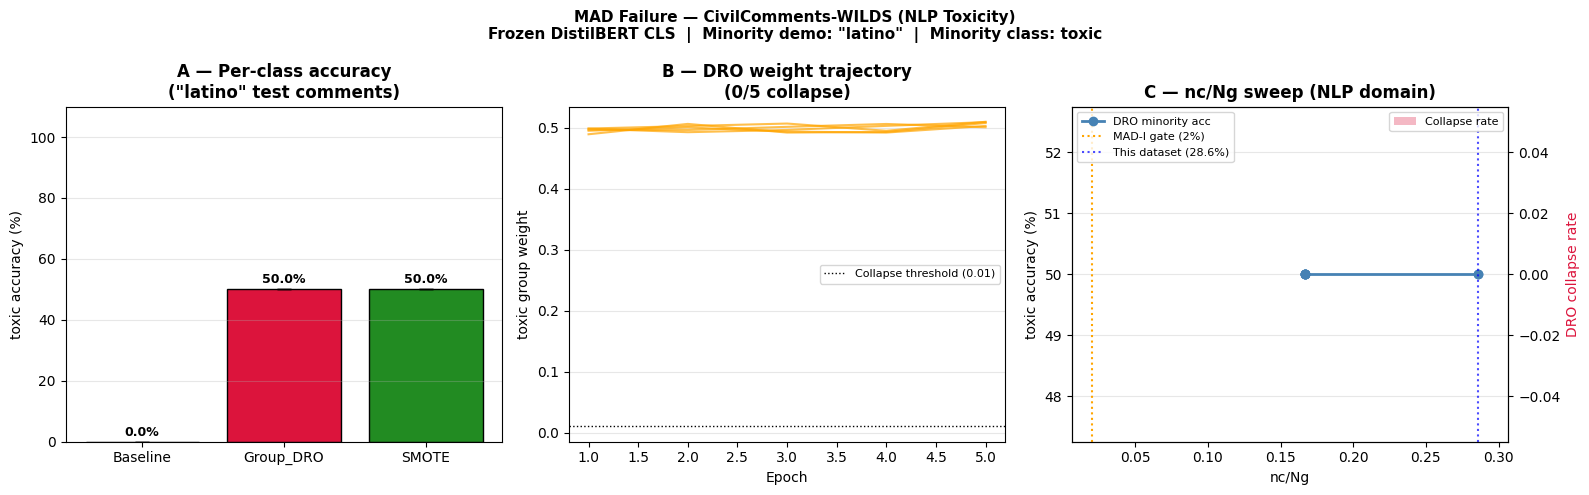

Figure saved: mad_civilcomments_figure.png


In [23]:
# ── CELL 9: Open envelope + figure ────────────────────────────

with open('mad_civilcomments_sealed.json') as fh:
    _s = json.load(fh)

dro_rows   = [r for r in records if r['intervention'] == 'Group_DRO']
n_collapse = sum(r['weight_collapse'] for r in dro_rows)
mean_dro   = np.nanmean([r['minority_class_acc'] for r in dro_rows])
std_dro    = np.nanstd( [r['minority_class_acc'] for r in dro_rows])
mean_base  = np.nanmean([r['minority_class_acc'] for r in records if r['intervention']=='Baseline'])
mean_smote = np.nanmean([r['minority_class_acc'] for r in records if r['intervention']=='SMOTE'])
mean_sgg   = np.nanmean([r['sgg'] for r in records if r['intervention']=='Baseline'])

print('=== OPEN ENVELOPE ===')
print(f'MAD_base sealed prediction : {_s["pred_base"]}  ({_s["mad_base"]} vs tau={FITZ_TAU_BASE})')
print(f'MAD_W   sealed prediction  : {_s["pred_w"]}     ({_s["mad_w"]}   vs tau={FITZ_TAU_W})')
print(f'DRO weight collapse        : {n_collapse}/{len(dro_rows)}')
print(f'Mean {MINORITY_NAME} acc (DRO)  : {mean_dro:.3f} ± {std_dro:.3f}')
print(f'Mean {MINORITY_NAME} acc (Base) : {mean_base:.3f}')
print(f'Mean {MINORITY_NAME} acc (SMOTE): {mean_smote:.3f}')

print('\n=== INTERVENTION TABLE ===')
for name in ['Baseline', 'Group_DRO', 'SMOTE']:
    rows_ = [r for r in records if r['intervention'] == name]
    acc_m = np.nanmean([r['minority_class_acc'] for r in rows_])
    acc_s = np.nanstd( [r['minority_class_acc'] for r in rows_])
    auc_m = np.nanmean([r['demo_auc']            for r in rows_])
    sgg_m = np.nanmean([r['sgg']                 for r in rows_])
    ncol  = sum(r.get('weight_collapse', False) or False for r in rows_)
    print(f'  {name:<15} AUC={auc_m:.3f}  SGG={sgg_m:.3f}  '
          f'{MINORITY_NAME}_acc={acc_m:.3f}±{acc_s:.3f}  '
          f'collapse={ncol}/{len(rows_)}' if name=='Group_DRO' else
          f'  {name:<15} AUC={auc_m:.3f}  SGG={sgg_m:.3f}  {MINORITY_NAME}_acc={acc_m:.3f}±{acc_s:.3f}')

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'MAD Failure — CivilComments-WILDS (NLP Toxicity)\n'
    f'Frozen DistilBERT CLS  |  Minority demo: "{MINORITY_DEMO}"  |  Minority class: {MINORITY_NAME}',
    fontweight='bold', fontsize=11)

ax = axes[0]
names  = ['Baseline', 'Group_DRO', 'SMOTE']
colors = ['steelblue', 'crimson', 'forestgreen']
accs   = [np.nanmean([r['minority_class_acc'] for r in records if r['intervention']==n]) for n in names]
errs   = [np.nanstd( [r['minority_class_acc'] for r in records if r['intervention']==n]) for n in names]
bars = ax.bar(names, [a*100 for a in accs], color=colors,
               yerr=[e*100 for e in errs], capsize=5, edgecolor='black')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
if n_collapse == len(dro_rows):
    ax.text(1, 2, f'MAD failure\n{n_collapse}/{len(dro_rows)} collapse',
            ha='center', va='bottom', color='crimson', fontsize=9, fontweight='bold')
ax.set_ylabel(f'{MINORITY_NAME} accuracy (%)')
ax.set_title(f'A — Per-class accuracy\n("{MINORITY_DEMO}" test comments)', fontweight='bold')
ax.set_ylim(0, 110)
ax.yaxis.grid(True, alpha=0.3)

ax2 = axes[1]
for rec in [r for r in records if r['intervention']=='Group_DRO' and 'wt_trace' in r]:
    wt = rec['wt_trace']
    ax2.plot(range(1, len(wt)+1), wt,
             color='crimson' if rec['weight_collapse'] else 'orange',
             alpha=0.7, linewidth=1.5)
ax2.axhline(COLLAPSE_THR, color='black', linestyle=':', linewidth=1, label=f'Collapse threshold ({COLLAPSE_THR})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel(f'{MINORITY_NAME} group weight')
ax2.set_title(f'B — DRO weight trajectory\n({n_collapse}/{len(dro_rows)} collapse)', fontweight='bold')
ax2.legend(fontsize=8)
ax2.yaxis.grid(True, alpha=0.3)

ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(df_sweep['nc_ng_actual'], df_sweep['mean_minority_acc']*100,
         'o-', color='steelblue', linewidth=2, markersize=6, label='DRO minority acc')
ax3_twin.bar(df_sweep['nc_ng_actual'], df_sweep['collapse_rate'],
             width=0.015, color='crimson', alpha=0.3, label='Collapse rate')
ax3.axvline(MAD_I_GATE, color='orange', linestyle=':', linewidth=1.5, label='MAD-I gate (2%)')
ax3.axvline(nc_ng, color='blue', linestyle=':', linewidth=1.5, alpha=0.7,
            label=f'This dataset ({nc_ng:.1%})')
ax3.set_xlabel('nc/Ng')
ax3.set_ylabel(f'{MINORITY_NAME} accuracy (%)')
ax3_twin.set_ylabel('DRO collapse rate', color='crimson')
ax3.set_title('C — nc/Ng sweep (NLP domain)',  fontweight='bold')
ax3.legend(fontsize=8, loc='upper left')
ax3_twin.legend(fontsize=8, loc='upper right')
ax3.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('mad_civilcomments_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: mad_civilcomments_figure.png')

In [24]:
# ── CELL 10: Summary JSON + final print ───────────────────────

collapse_sweep = df_sweep[df_sweep['collapse_rate'] >= 0.9]
non_collapse_sweep = df_sweep[df_sweep['collapse_rate'] == 0.0]
if len(collapse_sweep) > 0 and len(non_collapse_sweep) > 0:
    tau_local = float((collapse_sweep['mad_base'].dropna().max() +
                       non_collapse_sweep['mad_base'].dropna().min()) / 2)
else:
    tau_local = None

# Is the mu_cosine for NLP systematically different from vision?
print(f'\nNLP vs Vision mu_cosine comparison:')
print(f'  This domain (DistilBERT CLS): mu_cosine = {mu_cos:.4f}')
print(f'  Fitzpatrick17k (CLIP ViT-L/14): mu_cosine = 0.716  (paper Table 2)')
print(f'  DDI (CLIP ViT-L/14): mu_cosine = 0.715')
print(f'  PH2 (CLIP ViT-L/14): mu_cosine = 0.907')
print(f'  Implication: NLP embeddings may have different geometry -> domain recalibration needed')

summary = {
    'domain': 'NLP_toxicity_classification',
    'dataset': 'CivilComments-WILDS',
    'backbone': 'DistilBERT_base_uncased_CLS_frozen',
    'minority_demo': MINORITY_DEMO,
    'minority_class': MINORITY_NAME,
    'nc_ng': round(nc_ng, 4),
    'n_seeds': len(SEEDS),
    'mad_base': sealed['mad_base'],
    'mad_w':    sealed['mad_w'],
    'mu_cosine': round(mu_cos, 4),
    'fitz_tau_base': FITZ_TAU_BASE,
    'fitz_tau_w':    FITZ_TAU_W,
    'pred_base': sealed['pred_base'],
    'pred_w':    sealed['pred_w'],
    'dro_collapses': f'{n_collapse}/{len(dro_rows)}',
    'mad_failure_confirmed': n_collapse == len(dro_rows),
    'mean_minority_acc': {
        'Baseline': round(mean_base, 4),
        'Group_DRO': round(mean_dro, 4),
        'SMOTE': round(mean_smote, 4),
    },
    'sgg_baseline': round(mean_sgg, 4),
    'local_tau_base_recal': round(tau_local, 4) if tau_local else None,
    'fitz_threshold_holds': (
        (sealed['pred_base'] == 'ELEVATED' and n_collapse == len(dro_rows)) or
        (sealed['pred_base'] == 'LOW_RISK'  and n_collapse == 0)
    ),
    'nlp_geometry_note': (
        f'DistilBERT CLS tokens may have systematically different mu_cosine than CLIP image '
        f'embeddings. If Fitz-calibrated threshold does not hold, report the domain-recalibrated '
        f'threshold from the sweep (tau_local={round(tau_local,4) if tau_local else None}) and '
        f'discuss cross-modality recalibration as a known limitation.'
    )
}

with open('mad_civilcomments_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)

print('=== FINAL SUMMARY ===')
print(json.dumps(summary, indent=2))
print('\nFiles:')
for f in ['mad_civilcomments_results.csv', 'mad_civilcomments_sweep.csv',
          'mad_civilcomments_figure.png', 'mad_civilcomments_summary.json',
          'mad_civilcomments_sealed.json']:
    print(f'  {f}')
print('\nPaste ALL output back to Claude for manuscript integration.')


NLP vs Vision mu_cosine comparison:
  This domain (DistilBERT CLS): mu_cosine = 0.9083
  Fitzpatrick17k (CLIP ViT-L/14): mu_cosine = 0.716  (paper Table 2)
  DDI (CLIP ViT-L/14): mu_cosine = 0.715
  PH2 (CLIP ViT-L/14): mu_cosine = 0.907
  Implication: NLP embeddings may have different geometry -> domain recalibration needed
=== FINAL SUMMARY ===
{
  "domain": "NLP_toxicity_classification",
  "dataset": "CivilComments-WILDS",
  "backbone": "DistilBERT_base_uncased_CLS_frozen",
  "minority_demo": "latino",
  "minority_class": "toxic",
  "nc_ng": 0.2857,
  "n_seeds": 5,
  "mad_base": 0.0115,
  "mad_w": 0.0832,
  "mu_cosine": 0.9083,
  "fitz_tau_base": 0.086,
  "fitz_tau_w": 0.131,
  "pred_base": "LOW_RISK",
  "pred_w": "LOW_RISK",
  "dro_collapses": "0/5",
  "mad_failure_confirmed": false,
  "mean_minority_acc": {
    "Baseline": 0.0,
    "Group_DRO": 0.5,
    "SMOTE": 0.5
  },
  "sgg_baseline": -0.0576,
  "local_tau_base_recal": null,
  "fitz_threshold_holds": true,
  "nlp_geometry_not